<a href="https://colab.research.google.com/github/gautamkr1876/AIML_ClassNotes/blob/main/8.%20Agentic%20AI%20Systems/1.%20Asynchronous%20Programming%20%26%20Concurrency%20for%20AI/Asynchronous_Programming_%26_Concurrency_for_AI.ipynb" target="_blank">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# Async Python for LLM Applications

*A hands-on, classroom-friendly notebook for ML engineers who know Python but are new to async.*

---

## Learning Objectives

By the end of this notebook you will be able to:

1. **Explain why LLM applications need async** — and what "I/O-bound" really means.
2. **Write basic `async` / `await` code** and reason about the event loop.
3. **Use generators and `yield`** — and connect them to token streaming.
4. **Run requests in parallel** with `asyncio.gather`.
5. **Manage tasks safely** — timeouts, cancellation, partial failures.
6. **Apply common async patterns** used in real LLM systems: streaming, parallel tool calls, fan-out/fan-in.
7. **Build a live "Matrix Rain" capstone** — both as a notebook animation *and* an interactive Gradio app.

---

## Who this is for

- Python developers comfortable with functions, loops, and basic OOP.
- ML engineers who have used LLM APIs but always synchronously.
- Anyone who has felt their agent/chatbot is "slow for no reason".

**Not required:** prior experience with `asyncio`, threads, or concurrency theory.

---

## What you will build

<div style="background:linear-gradient(135deg,#0b3d0b,#000);color:#0f0;font-family:Menlo,Consolas,monospace;padding:18px;border-radius:10px;font-size:13.5px;line-height:1.55;border:1px solid #0f0;box-shadow:0 0 20px rgba(0,255,0,0.15);">
<div style="color:#6f6;margin-bottom:10px;">⏱ elapsed: 0.84s  |  3/5 complete</div>
<div>✓ <span style="color:#3f6;opacity:0.7;">[LLM-0]</span> <span>Transformers learn contextual representations via self-attention.</span></div>
<div>● <span style="color:#3f6;opacity:0.7;">[LLM-1]</span> <span>Quantization shrinks models by using</span><span style="color:#9f9;">▌</span></div>
<div>✓ <span style="color:#3f6;opacity:0.7;">[LLM-2]</span> <span>RAG augments LLMs with retrieved knowledge.</span></div>
<div>● <span style="color:#3f6;opacity:0.7;">[LLM-3]</span> <span>Agents chain LLM reasoning with tool</span><span style="color:#9f9;">▌</span></div>
<div>✓ <span style="color:#3f6;opacity:0.7;">[LLM-4]</span> <span>Streaming reduces perceived latency and enables live UX.</span></div>
</div>

A Matrix-styled dashboard running 5 concurrent LLM streams — all writing into the same display at the same time, on a single thread.

---

## Sections at a glance

| Section | Topic                                          |
|--------:|------------------------------------------------|
| A       | Why async matters for LLMs                     |
| B       | `async` / `await` fundamentals                 |
| C       | Generators and `yield`                         |
| D       | `asyncio.gather` — parallel calls              |
| E       | Task management & error handling               |
| F       | Real-world async patterns for LLMs             |
| G       | Capstone: Matrix-Rain (notebook + Gradio)      |
| H       | Recap, cheatsheet, exercises                   |

---

## Prerequisites

**Python** 3.9+. The workshop uses OpenAI's `AsyncOpenAI` client for the hands-on LLM calls. Run the Setup cell below and paste your API key into the `getpass` prompt (nothing is printed or saved to disk). Default model is `gpt-4o-mini`, and the whole notebook costs a fraction of a cent end-to-end.

**Environment.** The later sections assume a real notebook runtime (Jupyter, JupyterLab, or Colab), because they rely on:
- top-level `await` (in a plain `.py` script you'd wrap in `asyncio.run(main())`),
- live `display_handle.update(...)` for the Matrix Rain animation,
- Gradio's inline iframe (Colab) or local server on port 7860 (Jupyter) for the Section G.4 app.

VS Code's notebook editor works. The Gradio and OpenAI SDKs install on first run.


In [ ]:
# Standard-library imports used throughout the notebook.
# Nothing exotic — this should run on a fresh Python 3.9+ install.
import asyncio
import time
import random
import itertools
from IPython.display import display, clear_output, HTML

# Seed RNG so character delays and jitter are reproducible in class.
random.seed(42)

print("Ready. Python + asyncio loaded.")

Ready. Python + asyncio loaded.


---
# Setup — OpenAI API key

We use OpenAI's `AsyncOpenAI` client for most of the notebook (and its synchronous counterpart `OpenAI` once, in Section A, to make the blocking-call demo honest).

### What you need

- An OpenAI API key — run the cell below and paste it into the `getpass` prompt (nothing is printed or saved to disk).
- We default to **`gpt-4o-mini`** because it's cheap and fast. Swap to `gpt-4o` if you want nicer outputs.
- Expected cost for the whole notebook: a fraction of a cent (`max_tokens` is kept small throughout).


In [ ]:
# Install the openai SDK if it's not already present.
import importlib, subprocess, sys
if importlib.util.find_spec("openai") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "openai"])
    print("openai installed.")
else:
    print("openai already installed.")

openai already installed.


In [ ]:
# Prompt for the API key (only if not already set in the environment).
import os, getpass

if not os.environ.get("OPENAI_API_KEY"):
    os.environ["OPENAI_API_KEY"] = getpass.getpass("Enter your OpenAI API key: ")

# Two clients: sync for the blocking demo in Section A, async for everything else.
# Both read OPENAI_API_KEY from the environment automatically.
from openai import OpenAI, AsyncOpenAI
client  = OpenAI()
aclient = AsyncOpenAI()

# Default model for the whole notebook. Change to "gpt-4o" for higher quality
# (roughly 20x the cost).
MODEL = "gpt-4o-mini"

print(f"ready — using model: {MODEL}")

Enter your OpenAI API key: ··········
ready — using model: gpt-4o-mini


### A quick sanity check

One round-trip to confirm the key works before we continue.

In [ ]:
async def _sanity_check():
    resp = await aclient.chat.completions.create(
        model=MODEL,
        messages=[{"role": "user", "content": "Reply with exactly one word: READY"}],
        max_tokens=5,
    )
    print("model replied:", resp.choices[0].message.content.strip())

await _sanity_check()

model replied: READY


---
# Section A — Why async matters for LLMs

## The intuition

When your program calls an LLM API, **most of the time is spent waiting** — for the network, for the model server, for tokens to stream back. Your CPU is bored.

- **CPU-bound work:** math, tensor ops, sorting. The CPU is busy.
- **I/O-bound work:** HTTP calls, disk reads, DB queries, LLM APIs. The CPU is idle, waiting.

LLM apps are overwhelmingly **I/O-bound**. Sync code wastes this idle time.

## Sync vs async — side by side

<div style="text-align:center;margin:14px 0;">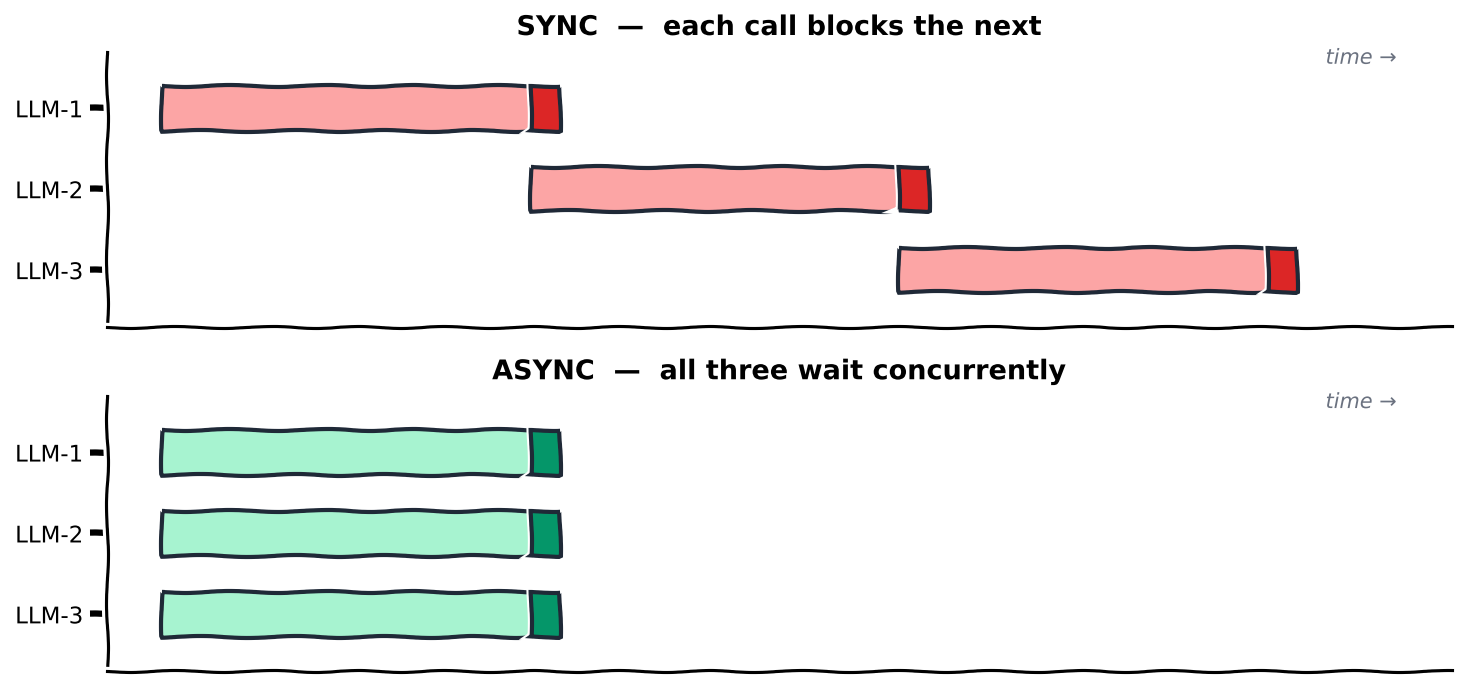</div>

In sync mode we wait serially. In async mode we **overlap the waits** — this is called *latency hiding*.


### A.1 — Blocking example (synchronous)

Three LLM calls, made one after the other with the synchronous `OpenAI` client. Each call fully blocks the Python thread until the HTTP response comes back.

In [ ]:
def ask_sync(prompt):
    # Using the SYNC OpenAI client. Nothing else can run on this thread while we wait.
    resp = client.chat.completions.create(
        model=MODEL,
        messages=[{"role": "user", "content": prompt}],
        max_tokens=20,
    )
    return resp.choices[0].message.content.strip()

t0 = time.perf_counter()

# Three calls, one after the other. Total ≈ sum of each individual latency.
r1 = ask_sync("In machine learning, in one short sentence, what is a transformer architecture?")
r2 = ask_sync("In transformer models, in one short sentence, what is attention?")
r3 = ask_sync("In LLM training, in one short sentence, what is RLHF?")

sync_elapsed = time.perf_counter() - t0
print(f"Sync total: {sync_elapsed:.2f}s")
print(r1); print(r2); print(r3)

Sync total: 3.44s
A transformer architecture is a deep learning model that utilizes self-attention mechanisms to process sequential data efficiently,
Attention in transformer models allows the model to weigh the importance of different input tokens when generating an output,
RLHF stands for Reinforcement Learning from Human Feedback, a method used to improve language models by incorporating


**Observation:** the total time is roughly the **sum** of the three round-trips. Each call fully blocks the next one.

### A.2 — Non-blocking example (asynchronous)

Same three prompts, same model, but dispatched concurrently with the async client. Each `await` on a network response hands control back to the event loop so another coroutine can make progress.

In [ ]:
async def ask_async(prompt):
    # Using the ASYNC client. `await` here yields control to the event loop
    # while the network round-trip is in flight — other coroutines keep running.
    resp = await aclient.chat.completions.create(
        model=MODEL,
        messages=[{"role": "user", "content": prompt}],
        max_tokens=20,
    )
    return resp.choices[0].message.content.strip()

async def run_three_concurrent():
    t0 = time.perf_counter()
    # gather() launches all three calls concurrently and waits for all to finish.
    r1, r2, r3 = await asyncio.gather(
        ask_async("In machine learning, in one short sentence, what is a transformer architecture?"),
        ask_async("In transformer models, in one short sentence, what is attention?"),
        ask_async("In LLM training, in one short sentence, what is RLHF?"),
    )
    elapsed = time.perf_counter() - t0
    print(f"Async total: {elapsed:.2f}s")
    for r in (r1, r2, r3): print(r)
    return elapsed

async_elapsed = await run_three_concurrent()

Async total: 1.30s
A transformer architecture is a deep learning model that uses self-attention mechanisms to process sequential data, enabling
Attention in transformer models is a mechanism that allows the model to focus on different parts of the input sequence
RLHF stands for Reinforcement Learning from Human Feedback, a technique used to fine-tune language models


**Observation:** the total time is closer to the **max** of the three round-trips, not the sum. That's latency hiding at work.

### A.3 — Visual timing comparison

Let's plot the two numbers we just measured.

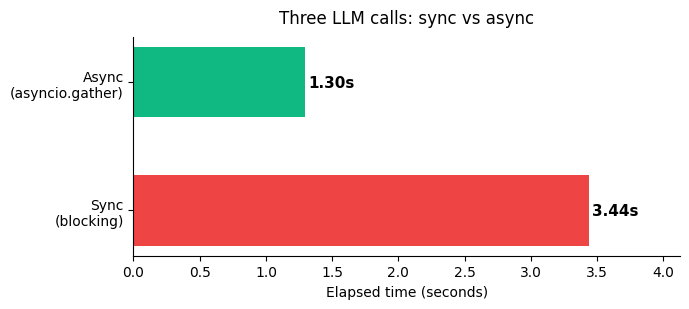

Speedup: 2.7×


In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 3.2))
labels = ['Sync\n(blocking)', 'Async\n(asyncio.gather)']
times = [sync_elapsed, async_elapsed]
colors = ['#ef4444', '#10b981']

bars = ax.barh(labels, times, color=colors, height=0.55)
ax.set_xlabel('Elapsed time (seconds)')
ax.set_title('Three LLM calls: sync vs async', pad=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

for bar, t in zip(bars, times):
    ax.text(t + 0.02, bar.get_y() + bar.get_height()/2, f'{t:.2f}s',
            va='center', fontsize=11, fontweight='bold')

ax.set_xlim(0, max(times) * 1.2)
plt.tight_layout()
plt.show()

print(f"Speedup: {sync_elapsed / async_elapsed:.1f}×")

### Key takeaways

- Async doesn't make any single call faster. It lets you **do other useful work while waiting**.
- Perfect fit for LLM APIs, HTTP requests, DB queries — anything I/O-bound.
- Bad fit for pure CPU work (use multiprocessing instead).
- In a notebook, `await` works directly at the top level of a cell. In a `.py` script you need `asyncio.run(main())`.


---
# Section B — `async` / `await` fundamentals

## Three concepts you need

1. **Coroutine function** — any function defined with `async def`.
2. **Coroutine object** — what you get when you *call* a coroutine function. It doesn't run yet!
3. **Event loop** — the scheduler that actually runs coroutines, pausing them at each `await`.

## Mental model — the event loop as a single waiter

<div style="text-align:center;margin:14px 0;">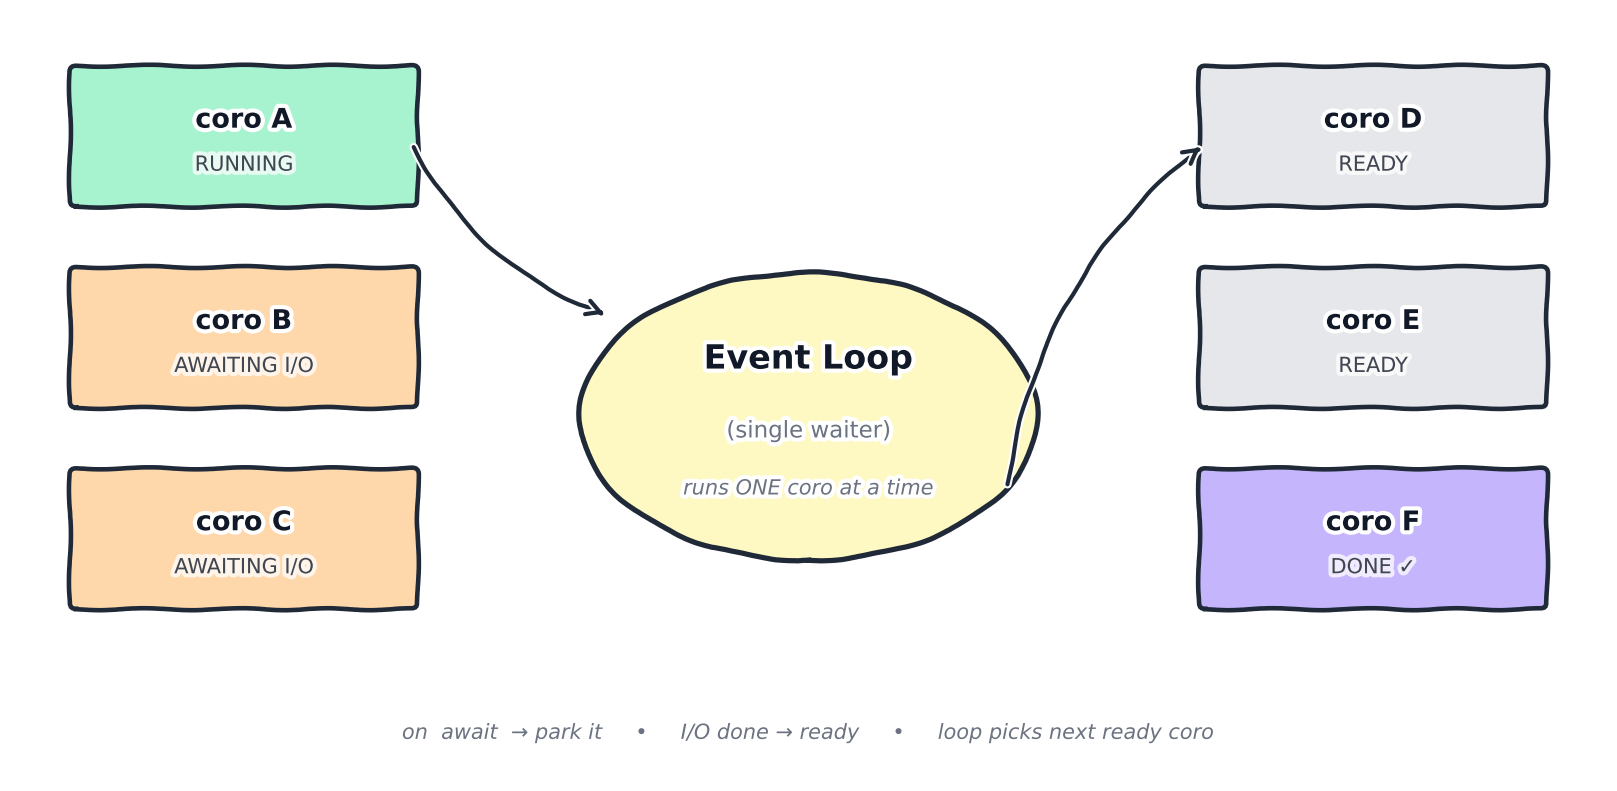</div>

**Analogy.** Picture a single waiter serving many tables. While one table reads the menu (awaits), the waiter takes another table's order. One person, many tables *in flight*. That's your event loop.

### B.1 — Calling a coroutine function does not run it

In [ ]:
async def greet(name):
    await asyncio.sleep(0.1)
    return f"hello, {name}"

# Calling it returns a coroutine OBJECT — not the result!
coro = greet("Ada")
print(type(coro), coro)

# You must `await` it (or schedule it on the loop) for it to actually run.
result = await coro
print("result:", result)

<class 'coroutine'> <coroutine object greet at 0x78b39ab66f80>
result: hello, Ada


### B.2 — Sequential `await` (no concurrency yet)

In [ ]:
async def sequential_demo():
    t0 = time.perf_counter()
    # Each `await` runs to completion before the next line starts.
    a = await greet("Ada")
    b = await greet("Babbage")
    c = await greet("Curie")
    print(a, b, c, sep=" | ")
    print(f"sequential: {time.perf_counter()-t0:.2f}s")

await sequential_demo()

hello, Ada | hello, Babbage | hello, Curie
sequential: 0.31s


Note: **sequential `await` is still ~0.3s** (3 × 0.1s). Using `async` alone is not enough — you must also express concurrency explicitly.

### B.3 — Concurrent execution with `gather`

In [ ]:
async def concurrent_demo():
    t0 = time.perf_counter()
    # gather starts all three AT ONCE and waits for all to finish.
    a, b, c = await asyncio.gather(
        greet("Ada"),
        greet("Babbage"),
        greet("Curie"),
    )
    print(a, b, c, sep=" | ")
    print(f"concurrent: {time.perf_counter()-t0:.2f}s")

await concurrent_demo()

hello, Ada | hello, Babbage | hello, Curie
concurrent: 0.10s


**~0.1s** — three 0.1s waits, fully overlapped.

### Key takeaways

- `async def` creates a **coroutine function**; calling it returns a coroutine object.
- `await` runs a coroutine and returns its result — sequentially by default.
- To get concurrency you must use `gather`, `create_task`, or similar primitives.
- The event loop runs **one thing at a time**, but switches whenever code hits `await`. This is *cooperative* multitasking.


---
# Section C — Generators and `yield`

Generators aren't async — but they're the conceptual bridge to **streaming**. LLM streaming APIs use the same "produce items lazily over time" idea.

## The core idea

- A **regular function** computes everything and `return`s one value.
- A **generator function** uses `yield` to produce values **one at a time, on demand**.

## Tokens arriving over time

<div style="text-align:center;margin:14px 0;">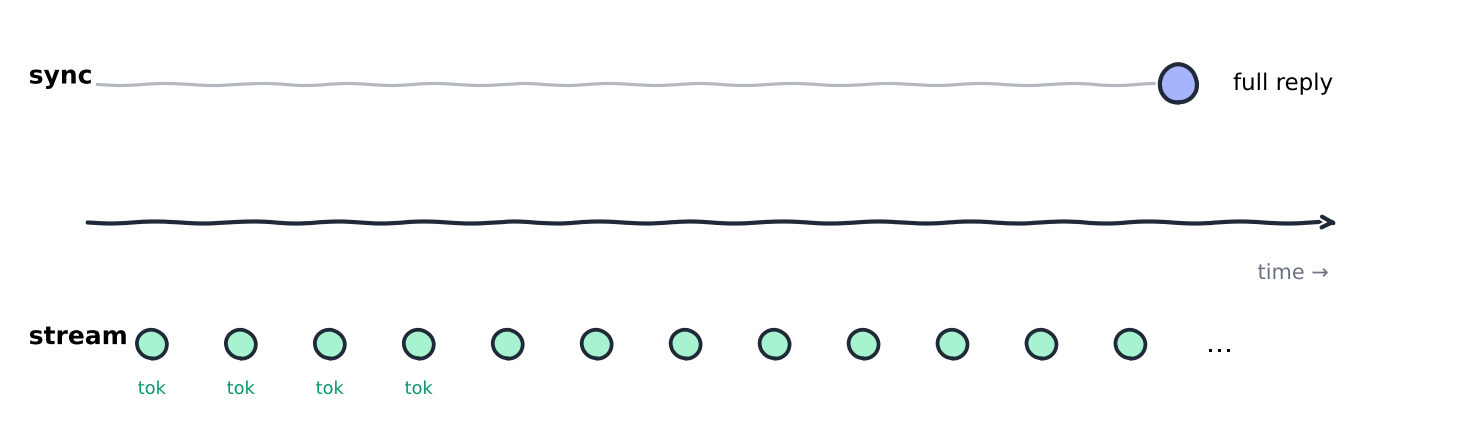</div>

Sync returns once everything is ready. Streaming yields each token as it is produced — perceived latency drops dramatically.


### C.1 — A minimal generator

In [ ]:
def countdown(n):
    # `yield` makes this a generator function. Calling it returns a generator object.
    while n > 0:
        yield n
        n -= 1

# Iterate lazily. Each step only computes one value.
for x in countdown(3):
    print("tick", x)

tick 3
tick 2
tick 1


### C.2 — A word/token generator

Tokens in LLM land are just small string fragments. Here we fake a tokenizer.

In [ ]:
def tokenize(sentence):
    # Pretend each word is a "token". Real tokenizers split subwords,
    # but this is enough to show the streaming idea.
    for word in sentence.split():
        yield word

for tok in tokenize("async python for LLM apps"):
    print(f"[tok] {tok}")

[tok] async
[tok] python
[tok] for
[tok] LLM
[tok] apps


### C.3 — Async generator: streaming an LLM

Combine `async def` + `yield` to get an **async generator** — values produced over time, *and* each step can `await`. OpenAI's streaming API already exposes chunks this way; we wrap it as a clean async generator for the rest of the notebook to consume.

In [ ]:
async def stream_llm(prompt, model=None, max_tokens=80):
    """Async generator that yields text chunks from OpenAI as they arrive."""
    stream = await aclient.chat.completions.create(
        model=model or MODEL,
        messages=[{"role": "user", "content": prompt}],
        max_tokens=max_tokens,
        stream=True,   # <-- this flips the response into an async iterator of chunks
    )
    async for chunk in stream:
        # Each chunk has a `delta` with the new bit of text (if any).
        delta = chunk.choices[0].delta.content or ""
        if delta:
            yield delta

# Consume the generator with `async for`. Prints tokens live as they arrive.
async def show_stream():
    print("> ", end="", flush=True)
    async for piece in stream_llm("In one short sentence, what is async I/O in Python?"):
        print(piece, end="", flush=True)
    print()

await show_stream()

> Async I/O in Python allows for concurrent execution of code by using non-blocking I/O operations, enabling efficient handling of multiple tasks without waiting for each one to complete.


### Why streaming matters for LLM UX

- **Perceived latency drops a lot** — users see the first word in ~100 ms instead of waiting for the full paragraph.
- **You can pipeline downstream work** — e.g. start TTS or display rendering before generation finishes.
- **Cancellation is cheap** — if the user stops reading, you stop consuming tokens and the server can free resources.

### Key takeaways

- `yield` pauses a function and returns a value without ending it.
- Regular generators = lazy sync sequences. Async generators = lazy async sequences.
- LLM streaming is literally an async generator of tokens.


---
# Section D — `asyncio.gather` — parallel calls

`gather` is your everyday tool for **running many coroutines concurrently** and collecting their results.

## Fan-out / fan-in

<div style="text-align:center;margin:14px 0;">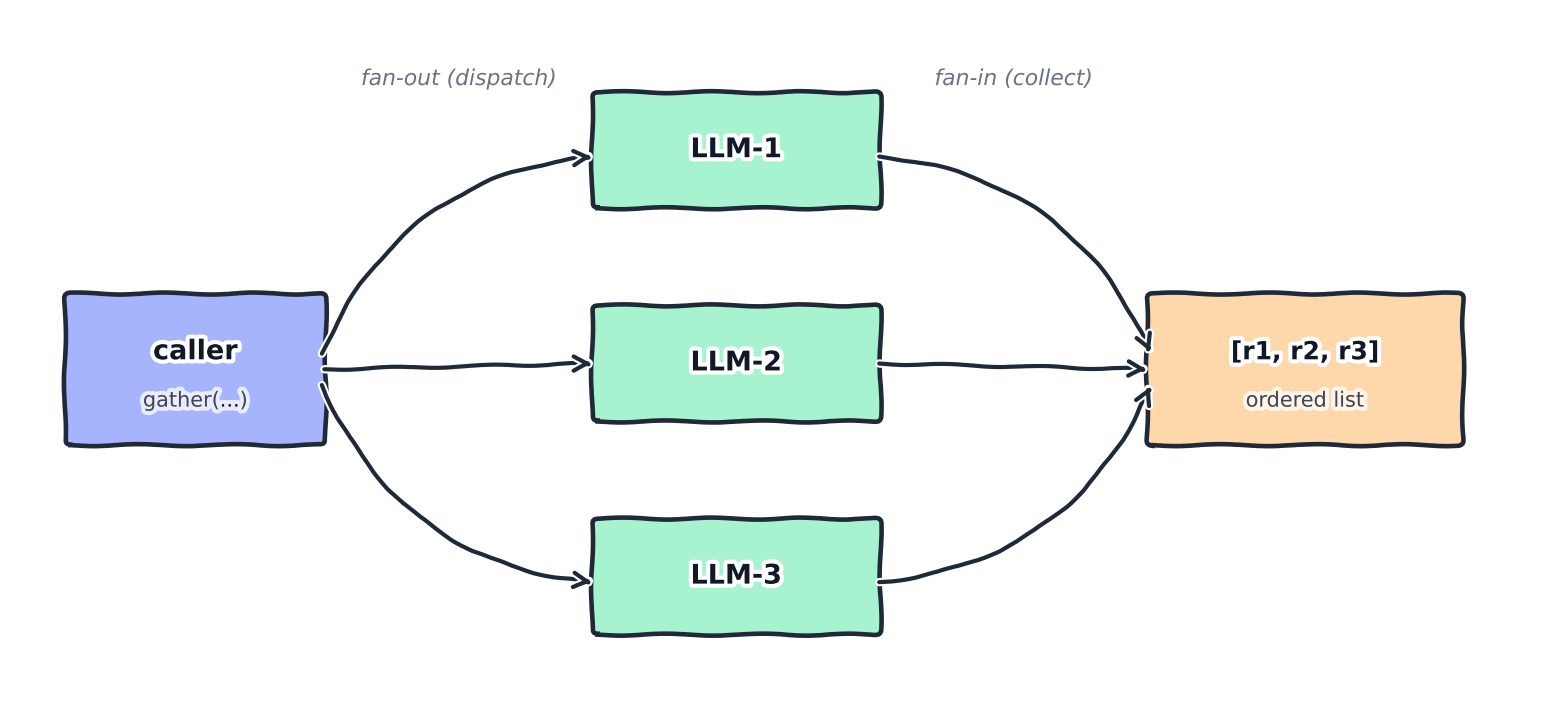</div>

Results come back **in the same order you passed them in** — regardless of which finished first.


### D.1 — Sequential vs concurrent timing

Same three LLM calls, dispatched two ways: sequentially with `await` in a loop, and concurrently with `gather`.

In [ ]:
async def _ask(prompt):
    resp = await aclient.chat.completions.create(
        model=MODEL,
        messages=[{"role": "user", "content": prompt}],
        max_tokens=20,
    )
    return resp.choices[0].message.content.strip()

PROMPTS_D1 = [
    "In ML, in one short sentence, what is dropout regularization?",
    "In deep learning, in one short sentence, what is a GPU used for?",
    "In NLP, in one short sentence, what is a word embedding?",
]

async def sequential():
    t0 = time.perf_counter()
    results = []
    for p in PROMPTS_D1:
        # Each await runs to completion before the next one starts.
        results.append(await _ask(p))
    print(f"sequential: {time.perf_counter()-t0:.2f}s")
    return results

async def concurrent():
    t0 = time.perf_counter()
    # gather() launches all three concurrently and waits for all to finish.
    results = await asyncio.gather(*(_ask(p) for p in PROMPTS_D1))
    print(f"concurrent: {time.perf_counter()-t0:.2f}s")
    return results

print(await sequential())
print(await concurrent())

sequential: 2.83s
['Dropout regularization is a technique used in neural networks to prevent overfitting by randomly removing a', 'A GPU is used in deep learning to accelerate the computation of large-scale matrix operations and neural network training', 'A word embedding is a numerical representation of words in a continuous vector space that captures their semantic meaning and']
concurrent: 0.84s
['Dropout regularization is a technique where randomly selected neurons are ignored during training to prevent overfitting', 'A GPU is used in deep learning to accelerate the training and inference of neural networks by performing parallel computations', 'A word embedding is a high-dimensional vector representation of words that captures their meanings and relationships based on context']


Sequential ≈ **sum** of individual latencies. Concurrent ≈ **max** of individual latencies.

### D.2 — Parallel LLM calls

The classic pattern: dispatch N independent prompts with `gather` and watch them finish in roughly the time of the slowest one.

In [ ]:
async def ask_llm(prompt, max_tokens=40):
    """One non-streaming OpenAI call. Returns the assistant's full reply."""
    resp = await aclient.chat.completions.create(
        model=MODEL,
        messages=[{"role": "user", "content": prompt}],
        max_tokens=max_tokens,
    )
    return resp.choices[0].message.content.strip()

prompts = [
    "In machine learning, in one short sentence, what is a transformer architecture?",
    "In transformer models, in one short sentence, what is attention?",
    "In ML, in one short sentence, what is dropout regularization?",
    "In LLM training, in one short sentence, what is RLHF?",
    "Name three popular neural-network optimizers (e.g. SGD, Adam), comma-separated, no prose.",
]

t0 = time.perf_counter()
# Fan out: 5 HTTP calls concurrently; gather preserves input order.
answers = await asyncio.gather(*(ask_llm(p) for p in prompts))
print(f"5 LLM calls in {time.perf_counter()-t0:.2f}s\n")
for p, a in zip(prompts, answers):
    print(f"Q: {p}\nA: {a}\n")

5 LLM calls in 1.10s

Q: In machine learning, in one short sentence, what is a transformer architecture?
A: A transformer architecture is a neural network design that utilizes self-attention mechanisms to process sequential data efficiently, allowing for parallelization and improved context understanding.

Q: In transformer models, in one short sentence, what is attention?
A: Attention in transformer models is a mechanism that allows the model to weigh the importance of different input elements when generating an output.

Q: In ML, in one short sentence, what is dropout regularization?
A: Dropout regularization is a technique that randomly deactivates a subset of neurons during training to prevent overfitting in neural networks.

Q: In LLM training, in one short sentence, what is RLHF?
A: RLHF stands for Reinforcement Learning from Human Feedback, a method used to fine-tune models based on human evaluations of their outputs.

Q: Name three popular neural-network optimizers (e.g. SGD, A

**Order preserved:** `answers[i]` matches `prompts[i]` even though each call took a different time.

### Key takeaways

- `asyncio.gather(*coros)` is the go-to primitive for parallel I/O.
- Result list is **in input order**, not completion order.
- Default behavior: if any coroutine raises, `gather` re-raises and cancels the rest. (We'll override this in Section E.)


---
# Section E — Task management and error handling

Real systems need more than "run these in parallel". You need to **start tasks in the background, cancel them, time them out, and survive partial failures**.

## The tools

| Primitive                      | What it does                                      |
|--------------------------------|---------------------------------------------------|
| `asyncio.create_task(coro)`    | Schedules a coroutine to run in the background.   |
| `task.cancel()`                | Requests cancellation.                            |
| `asyncio.wait_for(coro, t)`    | Awaits with a timeout; cancels on expiry.         |
| `asyncio.gather(..., return_exceptions=True)` | Keep going even if some tasks raise.  |
| `try/except` inside coroutines | Localize failures so they don't kill siblings.    |


### E.1 — `create_task` runs things in the background

In [ ]:
async def llm_worker(prompt):
    resp = await aclient.chat.completions.create(
        model=MODEL,
        messages=[{"role": "user", "content": prompt}],
        max_tokens=20,
    )
    return resp.choices[0].message.content.strip()

async def demo_create_task():
    # create_task() schedules the coroutine immediately — it starts running now.
    t1 = asyncio.create_task(llm_worker("In LLM fine-tuning, in one short sentence, what is LoRA?"))
    t2 = asyncio.create_task(llm_worker("In NLP, in one short sentence, what does a tokenizer do?"))

    # Do other work on the main coroutine while the LLM calls fly.
    print("main: kicked off 2 background LLM calls")
    print("main: doing other things while they run...")

    # Then collect the results.
    print("t1 ->", await t1)
    print("t2 ->", await t2)

await demo_create_task()

main: kicked off 2 background LLM calls
main: doing other things while they run...
t1 -> LoRA (Low-Rank Adaptation) is a technique for efficiently fine-tuning large language models
t2 -> A tokenizer splits text into smaller units, such as words or subwords, for easier processing in natural


### E.2 — Cancellation

A task can be cancelled while it's waiting on I/O. `task.cancel()` causes `CancelledError` to be raised *inside* the coroutine — which gives you a chance to clean up and re-raise.

In [ ]:
async def long_llm_call():
    try:
        print("task: sending a large-max_tokens request...")
        # A legitimately slow call: ask for a long response so it takes a while.
        resp = await aclient.chat.completions.create(
            model=MODEL,
            messages=[{"role": "user",
                       "content": "Write a detailed 500-word essay about async Python."}],
            max_tokens=1000,
        )
        return resp.choices[0].message.content.strip()
    except asyncio.CancelledError:
        # Clean up resources here if needed — close files, release locks, etc.
        print("task: was cancelled, cleaning up")
        raise  # re-raise so the cancellation is acknowledged

async def demo_cancel():
    task = asyncio.create_task(long_llm_call())
    # Let it start, then pull the plug almost immediately.
    await asyncio.sleep(0.2)
    task.cancel()
    try:
        await task
    except asyncio.CancelledError:
        print("main: confirmed task cancelled")

await demo_cancel()

task: sending a large-max_tokens request...
task: was cancelled, cleaning up
main: confirmed task cancelled


### E.3 — Timeouts with `wait_for`

Wrap an `await` in `asyncio.wait_for(coro, timeout=...)` to enforce a latency budget. If the coroutine doesn't finish in time, it's cancelled and `TimeoutError` is raised.

In [ ]:
async def demo_timeout():
    # A normal LLM call that, with max_tokens=1000, probably takes longer than 0.3s.
    # We wrap it in wait_for with a tight timeout to force the timeout path.
    slow = aclient.chat.completions.create(
        model=MODEL,
        messages=[{"role": "user",
                   "content": "Write a long detailed explanation of RLHF."}],
        max_tokens=1000,
    )
    try:
        resp = await asyncio.wait_for(slow, timeout=0.3)
        print("got:", resp.choices[0].message.content[:60])
    except asyncio.TimeoutError:
        print("timed out — fall back to cached answer or retry with a smaller budget")

await demo_timeout()

timed out — fall back to cached answer or retry with a smaller budget


### E.4 — One task fails, others keep running

By default, `gather` cancels siblings on the first failure. Pass `return_exceptions=True` to **collect exceptions as values** and let the other tasks finish. Here we deliberately mix valid calls with ones that hit an invalid model name, so the invalid ones raise real SDK exceptions.

In [ ]:
async def try_llm(prompt, model):
    # Intentionally lets SDK exceptions propagate.
    resp = await aclient.chat.completions.create(
        model=model,
        messages=[{"role": "user", "content": prompt}],
        max_tokens=15,
    )
    return resp.choices[0].message.content.strip()

BAD_MODEL = "definitely-not-a-real-model"

async def demo_partial_failure():
    results = await asyncio.gather(
        try_llm("In AI, in one short sentence, what is AGI?",                         MODEL),
        try_llm("In deep learning, in one short sentence, what is a GPU used for?",    BAD_MODEL),  # will raise
        try_llm("In ML, in one short sentence, what is model quantization?",           MODEL),
        try_llm("In LLM agents, in one short sentence, what is the ReAct pattern?",    BAD_MODEL),  # will raise
        return_exceptions=True,   # <-- the key flag: collect exceptions as values
    )
    for r in results:
        if isinstance(r, Exception):
            print(f"  FAILED: {type(r).__name__}: {str(r)[:80]}")
        else:
            print(f"  OK:     {r}")

await demo_partial_failure()

  OK:     AGI, or Artificial General Intelligence, is a form of AI that possesses
  FAILED: NotFoundError: Error code: 404 - {'error': {'message': 'The model `definitely-not-a-real-model`
  OK:     Model quantization is the process of reducing the numerical precision of the parameters and
  FAILED: NotFoundError: Error code: 404 - {'error': {'message': 'The model `definitely-not-a-real-model`


### Defensive pattern for production

Wrap each coroutine in its own `try/except` so a failure becomes a *value* (e.g. an error dict) rather than an exception. Then a plain `gather` without `return_exceptions=True` is safe — one bad call can't kill the batch, and your caller gets structured data back regardless.

In [ ]:
async def safe_ask_llm(prompt):
    try:
        resp = await aclient.chat.completions.create(
            model=MODEL,
            messages=[{"role": "user", "content": prompt}],
            max_tokens=15,
        )
        return {"prompt": prompt, "ok": True,
                "text": resp.choices[0].message.content.strip()}
    except Exception as e:
        # Localize the failure — caller sees a structured error, not an exception.
        return {"prompt": prompt, "ok": False, "error": f"{type(e).__name__}: {e}"}

prompts = [
    "In machine learning, in one short sentence, what is a transformer architecture?",
    "In transformer models, in one short sentence, what is attention?",
    "In ML, in one short sentence, what is dropout regularization?",
    "In LLM systems, in one short sentence, what is retrieval-augmented generation (RAG)?",
    "In LLMs, in one short sentence, what is a token?",
    "In deep learning, in one short sentence, what is mini-batch training?",
]
results = await asyncio.gather(*(safe_ask_llm(p) for p in prompts))
for r in results:
    print(r)

{'prompt': 'In machine learning, in one short sentence, what is a transformer architecture?', 'ok': True, 'text': 'A transformer architecture is a type of neural network designed for handling sequential data,'}
{'prompt': 'In transformer models, in one short sentence, what is attention?', 'ok': True, 'text': 'Attention in transformer models is a mechanism that allows the model to weigh the importance'}
{'prompt': 'In ML, in one short sentence, what is dropout regularization?', 'ok': True, 'text': 'Dropout regularization is a technique in neural networks where a random subset of'}
{'prompt': 'In LLM systems, in one short sentence, what is retrieval-augmented generation (RAG)?', 'ok': True, 'text': 'Retrieval-augmented generation (RAG) is a method that combines'}
{'prompt': 'In LLMs, in one short sentence, what is a token?', 'ok': True, 'text': 'A token is a basic unit of text that the model processes, which can'}
{'prompt': 'In deep learning, in one short sentence, what is mini-batch tr

### Key takeaways

- `create_task` = fire-and-remember background work.
- `task.cancel()` raises `CancelledError` inside the task — handle cleanup there.
- `wait_for(coro, timeout=...)` is your friend for bounded latency.
- `gather(..., return_exceptions=True)` to survive partial failure.
- For production: **wrap each coroutine in try/except and return a structured value**. Never let one bad call kill a whole batch.


---
# Section F — Real-world async patterns for LLMs

Four patterns you'll use constantly when building LLM applications:

1. **Streaming chat** — token-by-token output for responsiveness.
2. **Parallel tool execution** — an agent calls N tools at once.
3. **Fan-out / fan-in** — dispatch N prompts, merge the results.
4. **Partial-failure resilience** — one tool fails, the rest keep working.

## Agent with parallel tools

<div style="text-align:center;margin:14px 0;">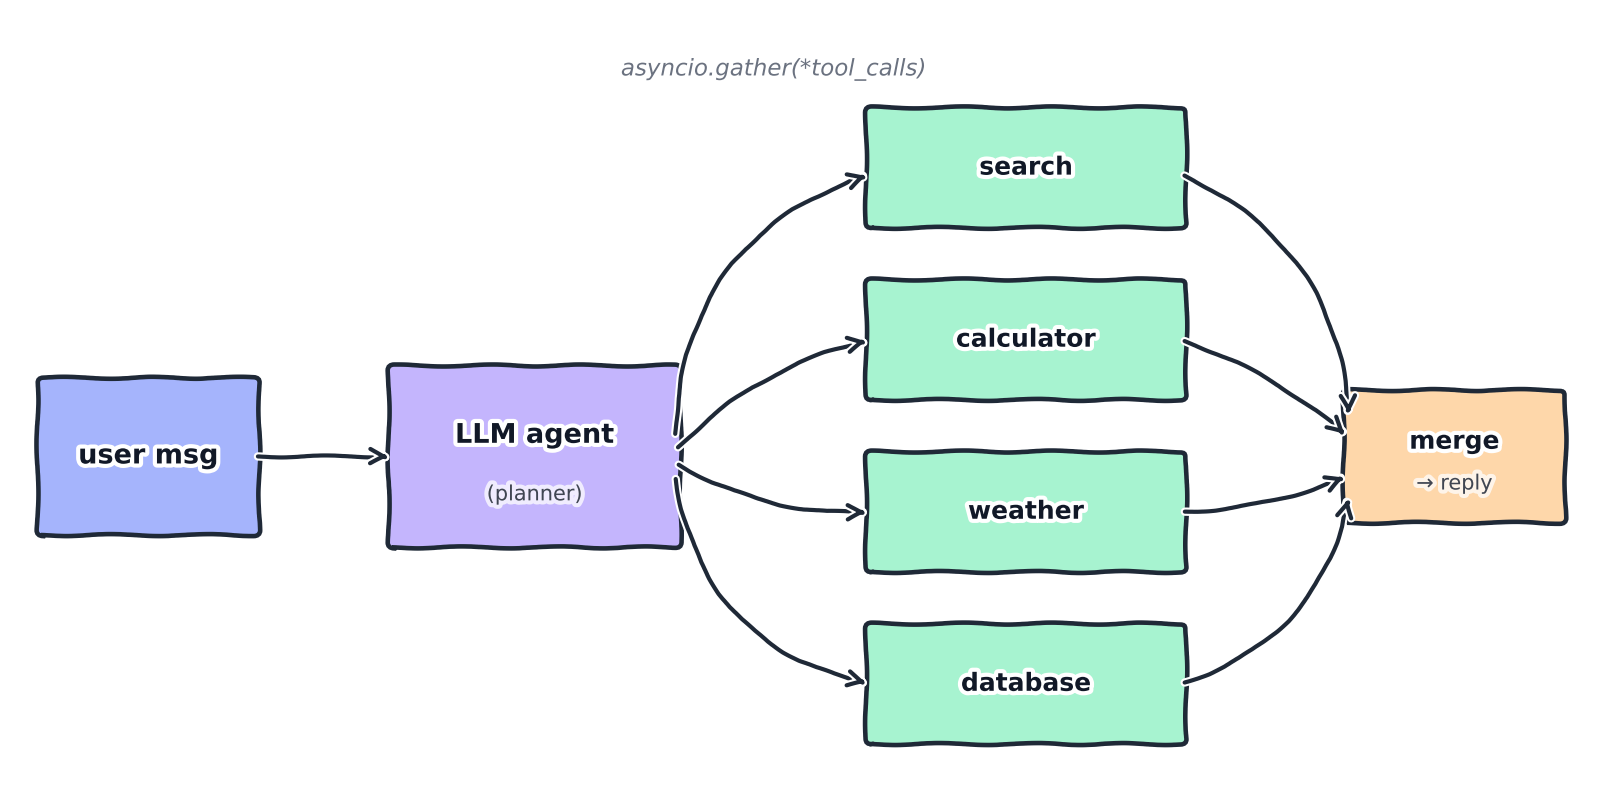</div>


### F.1 — Streaming chat

Reuses the `stream_llm` async generator from Section C.3 — same `async for` pattern, same perceived-latency win.

In [ ]:
async def run_chat(user_msg):
    print(f"user> {user_msg}")
    print("bot>  ", end="", flush=True)
    async for piece in stream_llm(user_msg, max_tokens=80):
        print(piece, end="", flush=True)
    print()

await run_chat("In transformer models, explain self-attention in two short sentences, no jargon.")

user> In transformer models, explain self-attention in two short sentences, no jargon.
bot>  Self-attention allows a model to weigh the importance of different words in a sentence relative to each other. This helps the model understand context and relationships between words more effectively.


### F.2 — Parallel tool execution

In [ ]:
# Pretend these are tools an LLM agent can call.
import ast
import operator as _op

# A safe evaluator for arithmetic expressions — replaces `eval()`, which
# would happily execute arbitrary Python. We walk a parsed AST and only
# accept numeric literals, a fixed set of binary/unary ops, and parens.
_ALLOWED_OPS = {
    ast.Add: _op.add, ast.Sub: _op.sub, ast.Mult: _op.mul,
    ast.Div: _op.truediv, ast.FloorDiv: _op.floordiv,
    ast.Mod: _op.mod, ast.Pow: _op.pow,
    ast.USub: _op.neg, ast.UAdd: _op.pos,
}

def safe_arith(expr: str):
    """Evaluate a purely numeric arithmetic expression. Raises ValueError otherwise."""
    def _ev(node):
        if isinstance(node, ast.Constant) and isinstance(node.value, (int, float)):
            return node.value
        if isinstance(node, ast.BinOp) and type(node.op) in _ALLOWED_OPS:
            return _ALLOWED_OPS[type(node.op)](_ev(node.left), _ev(node.right))
        if isinstance(node, ast.UnaryOp) and type(node.op) in _ALLOWED_OPS:
            return _ALLOWED_OPS[type(node.op)](_ev(node.operand))
        raise ValueError(f"disallowed expression: {ast.dump(node)}")
    tree = ast.parse(expr, mode="eval")
    return _ev(tree.body)

async def tool_search(query):
    await asyncio.sleep(random.uniform(0.3, 0.7))
    return {"tool": "search", "query": query, "hits": [f"doc_{i}" for i in range(3)]}

async def tool_calculator(expr):
    await asyncio.sleep(0.1)
    # Safe — only numeric literals and a fixed op set can run here.
    return {"tool": "calculator", "expr": expr, "result": safe_arith(expr)}

async def tool_weather(city):
    await asyncio.sleep(random.uniform(0.2, 0.5))
    return {"tool": "weather", "city": city, "temp_c": random.randint(10, 35)}

async def agent_step(user_msg):
    # The "planner" decides three tools must run. We run them all at once.
    t0 = time.perf_counter()
    tool_calls = [
        tool_search("latest GPU prices"),
        tool_calculator("23*19 + 42"),
        tool_weather("Hyderabad"),
    ]
    tool_results = await asyncio.gather(*tool_calls, return_exceptions=True)
    elapsed = time.perf_counter() - t0
    print(f"3 tools ran in {elapsed:.2f}s (vs ~{0.3+0.1+0.2:.1f}s+ sequentially)")
    for r in tool_results:
        print(" ", r)
    return tool_results

_ = await agent_step("plan my trip")

3 tools ran in 0.56s (vs ~0.6s+ sequentially)
  {'tool': 'search', 'query': 'latest GPU prices', 'hits': ['doc_0', 'doc_1', 'doc_2']}
  {'tool': 'calculator', 'expr': '23*19 + 42', 'result': 479}
  {'tool': 'weather', 'city': 'Hyderabad', 'temp_c': 18}


### F.3 — Fan-out / fan-in: batch LLM-as-judge scoring

In production, you rarely want truly unbounded `gather(...)` over an external API — 1,000 concurrent requests will hit rate limits, saturate connection pools, or simply anger your provider. The idiomatic fix is a shared **semaphore**: a simple counter that lets at most *N* coroutines through the critical section at once. All the others park on the `async with` until a slot frees up.

Here we keep the fan-out/fan-in pattern but cap it at 3 in-flight calls.

In [ ]:
# One semaphore, shared by every task. Cap concurrent in-flight API calls at 3.
API_SEMAPHORE = asyncio.Semaphore(3)

async def score_passage(passage):
    """Ask the model to rate how novel a passage is, 0.0-1.0.
    Bounded by API_SEMAPHORE — at most 3 of these run concurrently."""
    prompt = (
        "Rate the novelty of this ML passage on a scale 0.0 to 1.0. "
        "Reply with ONLY the number, nothing else.\n\n"
        f"Passage: {passage}"
    )
    # The `async with` acquires a slot; if all 3 are taken, this coroutine
    # parks here until one is released. Everything outside the `with` runs
    # without holding a slot — keep expensive setup out of the block.
    async with API_SEMAPHORE:
        resp = await aclient.chat.completions.create(
            model=MODEL,
            messages=[{"role": "user", "content": prompt}],
            max_tokens=8,
        )
    raw = resp.choices[0].message.content.strip()
    # Defensive parse — if the model adds stray text, fall back to 0.0.
    try:
        score = float(raw.split()[0])
    except (ValueError, IndexError):
        score = 0.0
    return {"passage": passage[:40] + "...", "score": score}

passages = [
    "Attention is all you need. The transformer replaces recurrence with self-attention.",
    "Retrieval augmented generation combines a retriever with a generator LLM.",
    "Reinforcement learning trains agents via reward signals from the environment.",
    "Quantization reduces model memory by using fewer bits per weight.",
    "LoRA adapts large models cheaply using low-rank weight updates.",
    "Mixture-of-experts activates different model subsets per input token.",
    "Streaming reduces perceived latency by emitting tokens as they are generated.",
]

t0 = time.perf_counter()
# Fan out all 7 — the semaphore keeps only 3 actually in flight at a time.
scored = await asyncio.gather(*(score_passage(p) for p in passages))
print(f"scored {len(passages)} passages in {time.perf_counter()-t0:.2f}s "
      f"(at most 3 concurrent in-flight)")

# Fan-in: merge into a ranked list.
ranked = sorted(scored, key=lambda x: x["score"], reverse=True)
print("\nRanked by model-judged novelty:")
for r in ranked:
    print(f"  {r['score']:.2f}  {r['passage']}")

scored 7 passages in 1.48s (at most 3 concurrent in-flight)

Ranked by model-judged novelty:
  0.30  Mixture-of-experts activates different m...
  0.20  Attention is all you need. The transform...
  0.20  LoRA adapts large models cheaply using l...
  0.20  Streaming reduces perceived latency by e...
  0.10  Retrieval augmented generation combines ...
  0.10  Reinforcement learning trains agents via...
  0.10  Quantization reduces model memory by usi...


### Where you'll see this in real LLM systems

- **Agent frameworks** (LangGraph, OpenAI Agents SDK) — every tool call is a coroutine.
- **Multi-model evaluation** — score one answer with 5 judge models in parallel.
- **RAG with reranking** — embed N queries, then rerank top-K, all concurrently.
- **Multi-step pipelines** — generate → critique → revise, with streaming at each step.

### Key takeaways

- Streaming = async generator of tokens.
- Parallel tools = `gather` over independent I/O coroutines.
- Fan-out/fan-in = dispatch many, merge into one.
- Always combine these with the defensive `try/except`-per-task pattern from Section E.


---
# Section G — Capstone: Matrix-Rain token streamer

**Goal.** Stream 5 LLM responses in parallel. Each call yields tokens as they arrive, and we paint them all into a single live display. Three renderings:

1. **Inline HTML animation** — updates in place inside the notebook cell (Matrix-style green on black).
2. **Plain-text fallback** — works in any terminal, uses `clear_output`.
3. **Interactive Gradio app** — sliders for number of LLMs and max tokens per stream.

## How the pieces fit together

<div style="text-align:center;margin:14px 0;">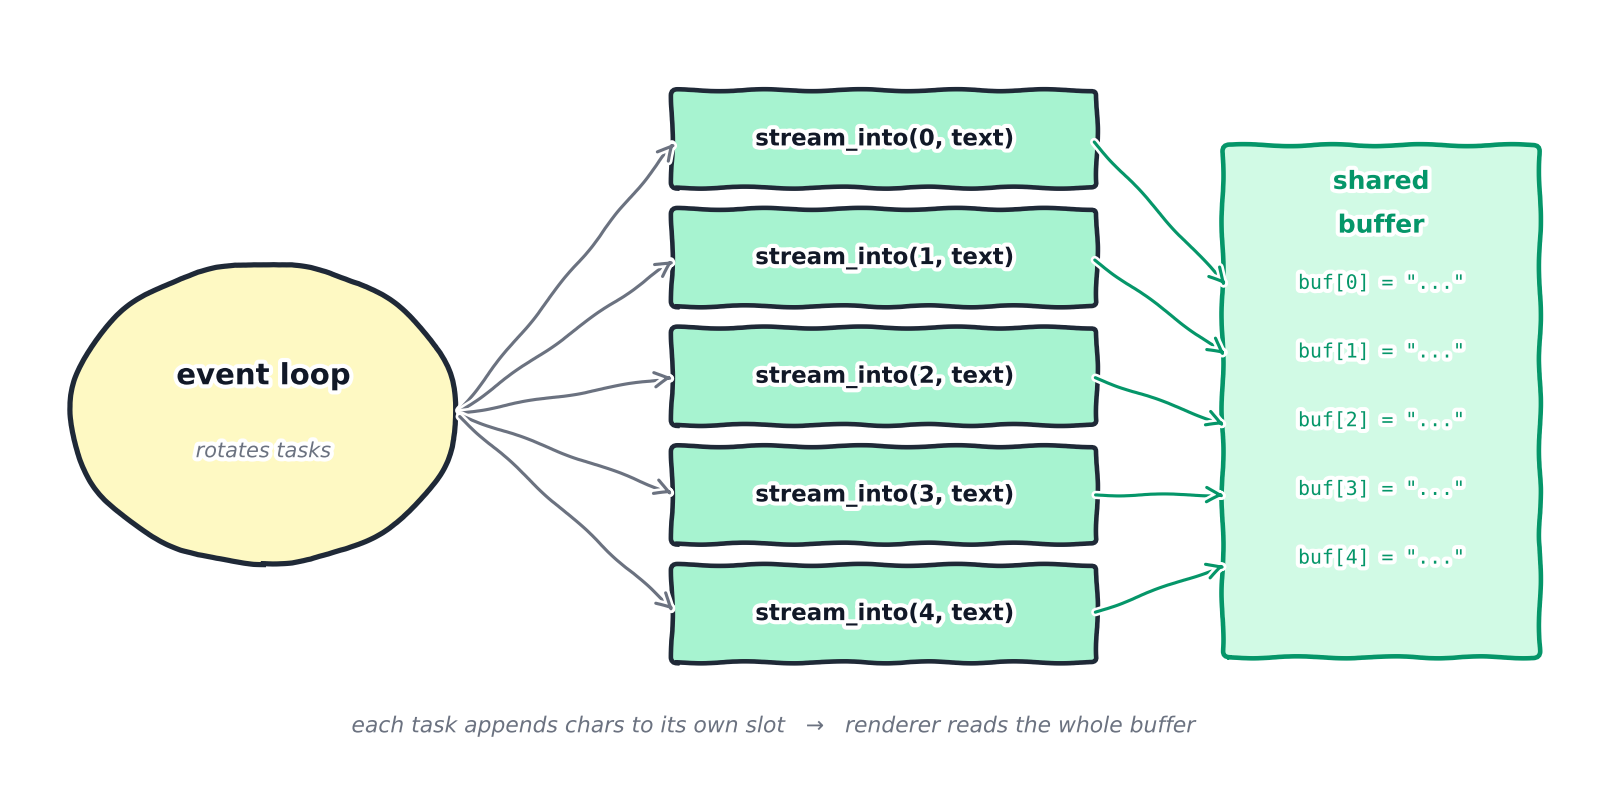</div>

No locks needed: only one coroutine runs at a time between `await`s, so writing to the buffer is inherently safe.


### G.1 — Shared setup

In [ ]:
# Prompts — one per concurrent "LLM stream". Each produces a different answer.
PROMPTS = [
    "In transformer models, in one short sentence, what do they learn?",
    "In ML, in one short sentence, what is model quantization?",
    "In LLM systems, in one short sentence, what is retrieval-augmented generation (RAG)?",
    "In AI, in one short sentence, what is an LLM agent?",
    "In LLM UX, in one short sentence, why is token streaming useful?",
    "In LLM fine-tuning, in one short sentence, what is LoRA?",
    "In LLM architectures, in one short sentence, what is mixture-of-experts?",
    "In LLM training, in one short sentence, what is RLHF?",
]

# Per-stream cap on tokens — keeps the demo fast and cheap.
STREAM_MAX_TOKENS = 50

### G.2 — HTML "Matrix Rain" version

Each of the 5 tasks is a streaming LLM call. The event loop rotates between them — one runs between `await`s while the other four wait on network chunks. Exactly the pattern you'd use in a production multi-LLM dashboard.

Two details worth noting — both pull directly from Section E's defensive patterns:

- **Per-task `try/except`.** If one stream errors out (rate limit, dropped connection, bad key), the others should keep flowing. We catch inside each `stream_into` so a single failure becomes an error state on one row, not a dead dashboard.
- **HTML escaping of model output.** Model text can contain `<`, `>`, or HTML-looking fragments (especially when the prompt asks for code). Injecting it directly into HTML breaks the display. `html.escape` is the one-liner fix.

In [ ]:
import html as _html

def render_html(buffer, done=None, errors=None, cursor=True):
    """Render the current buffer state as a Matrix-styled HTML block.
    Any streamed model text is passed through html.escape before injection."""
    n = len(buffer)
    if done is None:
        done = [False] * n
    if errors is None:
        errors = [None] * n

    rows_html = []
    for i, text in enumerate(buffer):
        is_done = done[i]
        err = errors[i]
        if err:
            status, status_color = '✗', '#f87171'   # red cross — this stream failed
        elif is_done:
            status, status_color = '✓', '#9f9'
        else:
            status, status_color = '●', '#ff0'

        caret = '' if is_done or err or not cursor else '<span style="color:#9f9;">▌</span>'
        safe_text = _html.escape(text)   # <-- escape model output before injecting
        body = safe_text
        if err:
            body += f' <span style="color:#f87171;">[{_html.escape(err)}]</span>'
        rows_html.append(
            f'<div style="margin:4px 0;line-height:1.5;">'
            f'<span style="color:{status_color};margin-right:6px;">{status}</span>'
            f'<span style="color:#3f6;opacity:0.7;">[LLM-{i}]</span> '
            f'<span style="color:#0f0;">{body}</span>{caret}'
            f'</div>'
        )

    n_done = sum(done)
    n_err = sum(1 for e in errors if e)
    header_bits = [f"{n_done}/{n} streams complete"]
    if n_err:
        header_bits.append(f'<span style="color:#f87171;">{n_err} failed</span>')
    header = "  |  ".join(header_bits)
    return HTML(
        f'<div style="background:linear-gradient(135deg,#0b3d0b,#000);color:#0f0;'
        f'font-family:Menlo,Consolas,monospace;padding:16px;border-radius:10px;'
        f'font-size:14px;border:1px solid #0f0;box-shadow:0 0 20px rgba(0,255,0,0.15);">'
        f'<div style="color:#6f6;margin-bottom:10px;">⏱ {header}</div>'
        f'{chr(10).join(rows_html)}</div>'
    )


async def stream_into(llm_id, prompt, buffer, done, errors, display_handle):
    """One async task per LLM: stream tokens into a buffer slot.
    Wrapped in try/except so a failure in one stream does not kill the others."""
    try:
        stream = await aclient.chat.completions.create(
            model=MODEL,
            messages=[{"role": "user", "content": prompt}],
            max_tokens=STREAM_MAX_TOKENS,
            stream=True,
        )
        async for chunk in stream:
            delta = chunk.choices[0].delta.content or ""
            if delta:
                buffer[llm_id] += delta
                display_handle.update(render_html(buffer, done, errors))
    except Exception as e:
        # Capture as a structured value; sibling streams keep running.
        errors[llm_id] = f"{type(e).__name__}: {e}"
    finally:
        done[llm_id] = True
        display_handle.update(render_html(buffer, done, errors))


async def matrix_rain_html(prompts=None):
    prompts = prompts or PROMPTS[:5]
    buffer = [""] * len(prompts)
    done = [False] * len(prompts)
    errors = [None] * len(prompts)
    handle = display(render_html(buffer, done, errors), display_id=True)

    # Kick off all streams in parallel. Because each coroutine catches its own
    # exceptions, we can use a plain gather here safely.
    tasks = [
        asyncio.create_task(stream_into(i, p, buffer, done, errors, handle))
        for i, p in enumerate(prompts)
    ]
    await asyncio.gather(*tasks)

    handle.update(render_html(buffer, done, errors, cursor=False))
    n_ok = sum(1 for d, e in zip(done, errors) if d and not e)
    n_bad = sum(1 for e in errors if e)
    print(f"\n✓ {n_ok} streams complete" + (f", {n_bad} failed" if n_bad else "") + ".")

await matrix_rain_html()


✓ 5 streams complete.


**What you just saw.** All five responses grow at the same time. No stream waits for another. Between `await`s on each stream, the event loop pivots to whichever other coroutine has a network chunk ready. That's how a single-threaded Python program keeps 5 HTTP conversations moving in parallel.

### G.3 — Plain-text fallback

If HTML rendering is stripped in your environment, use `clear_output(wait=True)` to redraw.

In [ ]:
async def stream_into_plain(llm_id, prompt, buffer, errors):
    try:
        stream = await aclient.chat.completions.create(
            model=MODEL,
            messages=[{"role": "user", "content": prompt}],
            max_tokens=STREAM_MAX_TOKENS,
            stream=True,
        )
        async for chunk in stream:
            delta = chunk.choices[0].delta.content or ""
            if delta:
                buffer[llm_id] += delta
                clear_output(wait=True)
                for i, row in enumerate(buffer):
                    tag = "✗" if errors[i] else ("✓" if row else " ")
                    suffix = f"  [ERROR: {errors[i]}]" if errors[i] else ""
                    print(f"{tag} [LLM-{i}] {row}{suffix}")
    except Exception as e:
        errors[llm_id] = f"{type(e).__name__}: {e}"

async def matrix_rain_plain():
    prompts = PROMPTS[:5]
    buffer = [""] * len(prompts)
    errors = [None] * len(prompts)
    tasks = [
        asyncio.create_task(stream_into_plain(i, p, buffer, errors))
        for i, p in enumerate(prompts)
    ]
    await asyncio.gather(*tasks)
    n_bad = sum(1 for e in errors if e)
    print(f"\n✓ {len(prompts) - n_bad} streams complete" + (f", {n_bad} failed" if n_bad else "") + ".")

await matrix_rain_plain()

✓ [LLM-0] Transformer models learn contextual relationships and patterns in sequential data, primarily for tasks like natural language processing.
✓ [LLM-1] Model quantization is the process of reducing the precision of the numbers used to represent a model's parameters, which helps to decrease its size and increase inference speed without significantly impacting accuracy.
✓ [LLM-2] Retrieval-augmented generation (RAG) is a technique that combines retrieval of relevant documents from a knowledge base with natural language generation to enhance the quality and accuracy of generated responses.
✓ [LLM-3] An LLM agent is a language model-based artificial intelligence that can understand and generate human-like text to perform tasks or answer questions autonomously.
✓ [LLM-4] Token streaming enhances the user experience by providing immediate feedback and reducing latency, allowing users to see responses develop in real-time.

✓ 5 streams complete.


### G.4 — Interactive Gradio demo 🎛

Now let's wrap the same async logic in a **Gradio UI** so you can tweak the number of streams and the token rate live.

Gradio supports async generator functions as event handlers — each `yield` becomes a UI update. This pairs perfectly with asyncio:

```
gradio UI  ──▶  async def handler(...):
                    while tasks running:
                        yield rendered_html     ◀── UI updates live
                    yield final_render
```

Install Gradio if it's not already available:

In [ ]:
# Install Gradio. Skip this if you already have it.
# On Colab this takes ~15 seconds the first time.
import importlib, subprocess, sys
if importlib.util.find_spec("gradio") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "gradio"])
    print("gradio installed.")
else:
    print("gradio already installed.")

gradio already installed.


**Build the app.** The core async logic is the same as Section G.2 — only the renderer and the driver are different.

In [ ]:
import gradio as gr
import html as _html

# ---- Renderer: take buffer state → HTML string ----
def render_matrix_gradio(buffer, done, errors, cancelled, elapsed):
    rows = []
    for i, text in enumerate(buffer):
        is_done = done[i]
        err = errors[i]
        was_cancelled = cancelled[i]
        # Priority: error > cancelled > done > running
        if err:
            status, status_color = '✗', '#f87171'
        elif was_cancelled:
            status, status_color = '⊘', '#fb923c'   # orange circle-slash for cancelled
        elif is_done:
            status, status_color = '✓', '#9f9'
        else:
            status, status_color = '●', '#ff0'
        caret = '' if is_done or err or was_cancelled else '<span style="color:#9f9;">▌</span>'

        body = _html.escape(text)  # escape streamed content before injecting
        if err:
            body += f' <span style="color:#f87171;">[{_html.escape(err)}]</span>'
        elif was_cancelled and not is_done:
            body += ' <span style="color:#fb923c;">[cancelled]</span>'
        rows.append(
            f'<div style="margin:4px 0;line-height:1.5;">'
            f'<span style="color:{status_color};margin-right:6px;">{status}</span>'
            f'<span style="color:#3f6;opacity:0.7;">[LLM-{i}]</span> '
            f'<span style="color:#0f0;">{body}</span>{caret}'
            f'</div>'
        )
    rows_html = "".join(rows)
    n_bad = sum(1 for e in errors if e)
    n_cancel = sum(1 for c in cancelled if c)
    notes = []
    if n_bad:
        notes.append(f'<span style="color:#f87171;">{n_bad} failed</span>')
    if n_cancel:
        notes.append(f'<span style="color:#fb923c;">{n_cancel} cancelled</span>')
    footer = ('' if not notes else ' &nbsp;|&nbsp; ' + ' &nbsp;|&nbsp; '.join(notes))
    return (
        '<div style="background:linear-gradient(135deg,#0b3d0b,#000);color:#0f0;'
        'font-family:Menlo,Consolas,monospace;padding:16px;border-radius:10px;'
        'font-size:14px;min-height:240px;border:1px solid #0f0;'
        'box-shadow:0 0 20px rgba(0,255,0,0.2);">'
        f'<div style="color:#6f6;margin-bottom:10px;">'
        f'⏱ elapsed: {elapsed:.2f}s &nbsp;|&nbsp; {sum(done)}/{len(done)} complete'
        f'{footer}</div>'
        f'{rows_html}</div>'
    )

# Module-level run state so the Stop button can reach the in-flight tasks.
# (One button, one run at a time — fine for a classroom demo.)
RUN_STATE = {"tasks": [], "cancelled_flags": None, "stopping": False}

# ---- Async generator that Gradio streams from ----
async def gradio_matrix_rain(num_streams, max_tokens):
    num_streams = int(num_streams)
    max_tokens = int(max_tokens)
    prompts = random.sample(PROMPTS, min(num_streams, len(PROMPTS)))

    buffer = [""] * len(prompts)
    done = [False] * len(prompts)
    errors = [None] * len(prompts)
    cancelled = [False] * len(prompts)

    # Publish state so gradio_stop() can cancel the current run.
    RUN_STATE["tasks"] = []
    RUN_STATE["cancelled_flags"] = cancelled
    RUN_STATE["stopping"] = False

    t0 = time.perf_counter()

    async def stream(idx, prompt):
        # Per-task try/except + CancelledError handler keeps one failure
        # or one cancellation from taking down the whole dashboard.
        try:
            resp = await aclient.chat.completions.create(
                model=MODEL,
                messages=[{"role": "user", "content": prompt}],
                max_tokens=max_tokens,
                stream=True,
            )
            async for chunk in resp:
                delta = chunk.choices[0].delta.content or ""
                if delta:
                    buffer[idx] += delta
        except asyncio.CancelledError:
            cancelled[idx] = True
            raise   # propagate so the task truly ends
        except Exception as e:
            errors[idx] = f"{type(e).__name__}: {e}"
        finally:
            done[idx] = True

    tasks = [asyncio.create_task(stream(i, p)) for i, p in enumerate(prompts)]
    RUN_STATE["tasks"] = tasks

    # Yield HTML updates at ~20 FPS while the streams run.
    while not all(t.done() for t in tasks):
        yield render_matrix_gradio(buffer, done, errors, cancelled,
                                   time.perf_counter() - t0)
        await asyncio.sleep(0.05)

    # Collect (but swallow CancelledError so the generator exits cleanly).
    await asyncio.gather(*tasks, return_exceptions=True)
    yield render_matrix_gradio(buffer, done, errors, cancelled,
                               time.perf_counter() - t0)

# ---- Stop button handler: cancel every in-flight task ----
def gradio_stop():
    RUN_STATE["stopping"] = True
    for t in RUN_STATE["tasks"]:
        if not t.done():
            t.cancel()
    # The generator above will observe the cancellations on its next tick
    # and render the final cancelled state.

# ---- Build the UI ----
with gr.Blocks(title="Async Matrix Rain", theme=gr.themes.Soft()) as demo:
    gr.Markdown(
        "## 🟢 Matrix Rain — concurrent LLM streams\n"
        "Watch 1–8 concurrent LLM calls stream tokens in parallel on a single thread. "
        "Hit **Start**, or **Stop** to cancel any in-flight calls — cancelled streams "
        "show as ⊘, failed ones as ✗, and the rest keep running either way."
    )
    with gr.Row():
        num_streams = gr.Slider(1, 8, value=5, step=1, label="Number of LLMs")
        max_tokens = gr.Slider(20, 120, value=50, step=10, label="Max tokens per stream")
    with gr.Row():
        start_btn = gr.Button("▶  Start streaming", variant="primary")
        stop_btn = gr.Button("⏹  Stop", variant="stop")
    output = gr.HTML()
    start_btn.click(gradio_matrix_rain,
                    inputs=[num_streams, max_tokens],
                    outputs=output)
    stop_btn.click(gradio_stop)

print("Gradio app built. Launch in the next cell.")

/tmp/ipykernel_934/692685424.py:122: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(title="Async Matrix Rain", theme=gr.themes.Soft()) as demo:


Gradio app built. Launch in the next cell.


Launch the app. On Colab it runs in an iframe inside the cell; on local Jupyter it opens at `http://127.0.0.1:7860`.

In [ ]:
# quiet=True suppresses Gradio's startup banner.
# share=False keeps it local; set True to get a public tunnel URL.
demo.queue().launch(inline=True, quiet=True, share=False)

<IPython.core.display.Javascript object>

### Walkthrough — what the capstone teaches

- **One event loop, many coroutines.** Up to 8 tasks run concurrently on a single thread.
- **Shared state is safe between `await`s.** The buffer is mutated by many tasks, but only one runs at a time, so no locks are needed.
- **Network I/O is the scheduling opportunity.** Every `await` on `resp = await aclient.chat.completions.create(...)` or `async for chunk in resp` hands control back to the event loop, letting the other streams make progress while this one waits on bytes.
- **Gradio + async generators = zero extra plumbing.** The `yield` pattern you learned in Section C is exactly what Gradio expects for streaming UIs.
- **Per-task `try/except` makes failures local.** Section E's defensive pattern isn't decorative — it's what keeps a single rate-limit blip from killing the whole dashboard.

Swap `gpt-4o-mini` for any other provider's async streaming client — Anthropic, Mistral, local vLLM — and the entire structure ports over unchanged.


---
# Section H — Recap, cheatsheet, exercises

## Summary

- LLM apps are I/O-bound → async is a big win.
- `async def` + `await` + event loop = cooperative concurrency on one thread.
- `gather` runs coroutines in parallel and preserves input order.
- `create_task`, `wait_for`, `CancelledError` let you manage lifecycle and timeouts.
- `return_exceptions=True` + per-task `try/except` = resilient batches.
- Generators (`yield`) and async generators (`async def` + `yield`) are the shape of streaming.
- Everyday LLM patterns: streaming, parallel tools, fan-out/fan-in.
- Gradio's streaming UIs are async generators in disguise.


## Cheatsheet

| Task                                   | Snippet                                                          |
|----------------------------------------|------------------------------------------------------------------|
| Define a coroutine                     | `async def f(x): ...`                                            |
| Await a coroutine                      | `result = await f(x)`                                            |
| Run in Jupyter cell                    | `await main()`  &nbsp; *(top-level await)*                       |
| Run from a `.py` script                | `asyncio.run(main())`                                            |
| Run many in parallel                   | `await asyncio.gather(*coros)`                                   |
| Run in background                      | `t = asyncio.create_task(coro)`                                  |
| Cancel a task                          | `t.cancel()` &nbsp; — &nbsp; handle `asyncio.CancelledError`     |
| Timeout                                | `await asyncio.wait_for(coro, timeout=2.0)`                      |
| Survive partial failures               | `gather(..., return_exceptions=True)`                            |
| Streaming producer                     | `async def gen(): ...; yield tok`                                |
| Streaming consumer                     | `async for tok in gen(): ...`                                    |
| Wait for first to finish               | `done, pending = await asyncio.wait(coros, return_when=FIRST_COMPLETED)` |
| Limit concurrency                      | `sem = asyncio.Semaphore(10); async with sem: ...`               |
| Gradio streaming handler               | `async def fn(...): ...; yield ui_update`                        |

## Common pitfalls

- **Forgetting `await`** — you get a coroutine object, not a result. (Python warns you.)
- **Using `time.sleep` in async code** — it blocks the whole event loop. Use `asyncio.sleep`.
- **CPU-heavy work in a coroutine** — also blocks the loop. Offload with `asyncio.to_thread` or a process pool.
- **Unbounded concurrency** — 10,000 parallel requests will crash your rate limit. Use a `Semaphore`.


## Exercises (try these now)

1. **Retry with backoff.** Wrap `safe_ask_llm` so it retries up to 3 times with exponential backoff (0.1s, 0.2s, 0.4s) before giving up.
2. **Instrument the semaphore.** The fan-out in Section F.3 already uses `API_SEMAPHORE = asyncio.Semaphore(3)`. Change the limit to 1, then 2, then 7 and measure how total runtime scales. Make a small table of your results.
3. **First-to-finish.** Given 3 different simulated LLMs answering the same question, return whichever responds first and cancel the rest. (Hint: `asyncio.wait` with `FIRST_COMPLETED`.)
4. **Streaming with early stop.** Modify `chat_stream` so the consumer can stop after N tokens without leaving the generator dangling. Confirm the generator is cleaned up (use `break` inside `async for`).
5. **Gradio upgrade.** Add a "Stop" button to the Matrix Rain app that cancels all running tasks. Display "Cancelled" per stream that didn't finish. (Hint: keep a reference to the tasks on a shared state object.)


## Conceptual / interview questions

1. **What's the difference between concurrency and parallelism?** Where does `asyncio` fit?
2. **Why does `time.sleep(5)` inside an `async def` break async behavior**, while `await asyncio.sleep(5)` does not?
3. **Explain what happens when you call an `async def` function without `await`ing it.** What does Python give you back, and what warning might you see?
4. **When would you choose `asyncio.create_task` over `asyncio.gather`?** Give one real scenario.
5. **What's the risk of using a plain `gather(...)` over 1,000 coroutines hitting the same API, and how do you fix it?** (Name at least two mitigations.)


## Next steps / further reading

- **Official docs:** [`asyncio` — the Python async stdlib](https://docs.python.org/3/library/asyncio.html).
- **PEP 492** — introduction of `async` / `await`.
- **`httpx` async client** — drop-in replacement for `requests` that supports `await`.
- **`anyio`** — structured concurrency, works across asyncio and trio.
- **`aiolimiter` / `asyncio.Semaphore`** — rate limiting patterns.
- **Gradio streaming docs** — https://www.gradio.app/guides/streaming-outputs
- **Streaming SDKs** — most LLM provider SDKs (OpenAI, Anthropic, etc.) expose `async` clients and streaming iterators. The patterns you practiced here port over almost unchanged.

---

*Thanks for attending. Questions? Drop them in chat.* 🎉
